In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from cmcrameri import cm

In [14]:
from emission_process import GlobalEmissionProcessor
import xarray as xr 

ds_eagrid = xr.open_dataset('Emission_grid_all.nc')
cams_path = "CAMS-GLOB-ANT_Glb_0.1x0.1_anthro_nox_v6.2_yearly_2010.nc"
camsds = xr.open_dataset(cams_path)
processor = GlobalEmissionProcessor(camsds, ds_eagrid)

processor.load_cams()
processor.load_eagrid()
processor.build_target_grid()
def extract_original_eagrid(processor, lon_center, lat_center, cams_pix=5):

    size = cams_pix * processor.k
    half = size // 2

    # center in fine grid
    ix = np.argmin(np.abs(processor.eagrid_lon - lon_center))
    iy = np.argmin(np.abs(processor.eagrid_lat - lat_center))

    lon_min = processor.eagrid_lon[ix-half]
    lon_max = processor.eagrid_lon[ix+half]

    lat_min = processor.eagrid_lat[iy-half]
    lat_max = processor.eagrid_lat[iy+half]

    # find indices in original EAGrid
    ix0 = np.searchsorted(processor.eagrid_lon_src, lon_min)
    ix1 = np.searchsorted(processor.eagrid_lon_src, lon_max)

    iy0 = np.searchsorted(processor.eagrid_lat_src, lat_min)
    iy1 = np.searchsorted(processor.eagrid_lat_src, lat_max)

    window = processor.eagrid_emission[iy0:iy1, ix0:ix1]

    return window

0.01
0.01


In [ ]:



def plot_testdata(center_lon, center_lat):

    # -------------------------
    # load saved dataset
    # -------------------------
    center_lon_array = np.load("created_data/center_lon_test.npy")
    center_lat_array = np.load("created_data/center_lat_test.npy")

    cams_bili_dataset = np.load("created_data/cams_bili_test.npy")
    cams_conserv_dataset = np.load("created_data/cams_conserv_test.npy")
    eagrid_dataset = np.load("created_data/eagrid_dataset_test.npy")

    # -------------------------
    # find nearest center
    # -------------------------
    dist = np.sqrt(
        (center_lon_array - center_lon)**2 +
        (center_lat_array - center_lat)**2
    )

    idx = np.argmin(dist)

    print("Selected index:", idx)
    print("Location:", center_lon_array[idx], center_lat_array[idx])

    # -------------------------
    # extract grids
    # -------------------------
    cams_bili = cams_bili_dataset[idx]
    cams_conserv = cams_conserv_dataset[idx]

    lon = center_lon_array[idx]
    lat = center_lat_array[idx]

    eagrid_before = extract_original_eagrid(processor, lon, lat)
    eagrid_after = eagrid_dataset[idx]   
    # simple coordinates (50x50 window)
    x = np.arange(cams_bili.shape[1])
    y = np.arange(cams_bili.shape[0])

    cmap = cm.roma_r
    norm = mcolors.Normalize(vmin=2.5, vmax=6.5)

    # =====================================================
    # CAMS before / after
    # =====================================================
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    ax = axes[0]
    sc = ax.pcolormesh(
        x, y, np.log10(cams_conserv),
        cmap=cmap, norm=norm,
        edgecolors='lightgray', linewidth=0.2
    )

    cb = plt.colorbar(sc, ax=ax, shrink=0.7, aspect=20, fraction=0.046)
    cb.ax.tick_params(labelsize=7)
    cb.set_label('conserv', fontsize=7)

    ax.set_title('cams conserv', fontsize=10)


    ax = axes[1]
    sc = ax.pcolormesh(
        x, y, np.log10(cams_bili),
        cmap=cmap, norm=norm,
        edgecolors='lightgray', linewidth=0.2
    )

    cb = plt.colorbar(sc, ax=ax, shrink=0.7, aspect=20, fraction=0.046)
    cb.ax.tick_params(labelsize=7)
    cb.set_label('cams bilinear', fontsize=7)

    ax.set_title('cams bilinear', fontsize=10)

    plt.title('CAMS')
    plt.tight_layout()
    plt.show()

    # =====================================================
    # EAGrid before / after
    # =====================================================
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    ax = axes[0]
    sc = ax.pcolormesh(
        x, y, np.log10(eagrid_before),
        cmap=cmap, norm=norm,
        edgecolors='lightgray', linewidth=0.2
    )

    cb = plt.colorbar(sc, ax=ax, shrink=0.7, aspect=20, fraction=0.046)
    cb.ax.tick_params(labelsize=7)
    cb.set_label('before', fontsize=7)

    ax.set_title('Before', fontsize=10)


    ax = axes[1]
    sc = ax.pcolormesh(
        x, y, np.log10(eagrid_after),
        cmap=cmap, norm=norm,
        edgecolors='lightgray', linewidth=0.2
    )

    cb = plt.colorbar(sc, ax=ax, shrink=0.7, aspect=20, fraction=0.046)
    cb.ax.tick_params(labelsize=7)
    cb.set_label('after', fontsize=7)

    ax.set_title('After', fontsize=10)

    plt.title('EAGrid')
    plt.tight_layout()
    plt.show()

Selected index: 1435
Location: 139.72499999999906 35.65000000000016


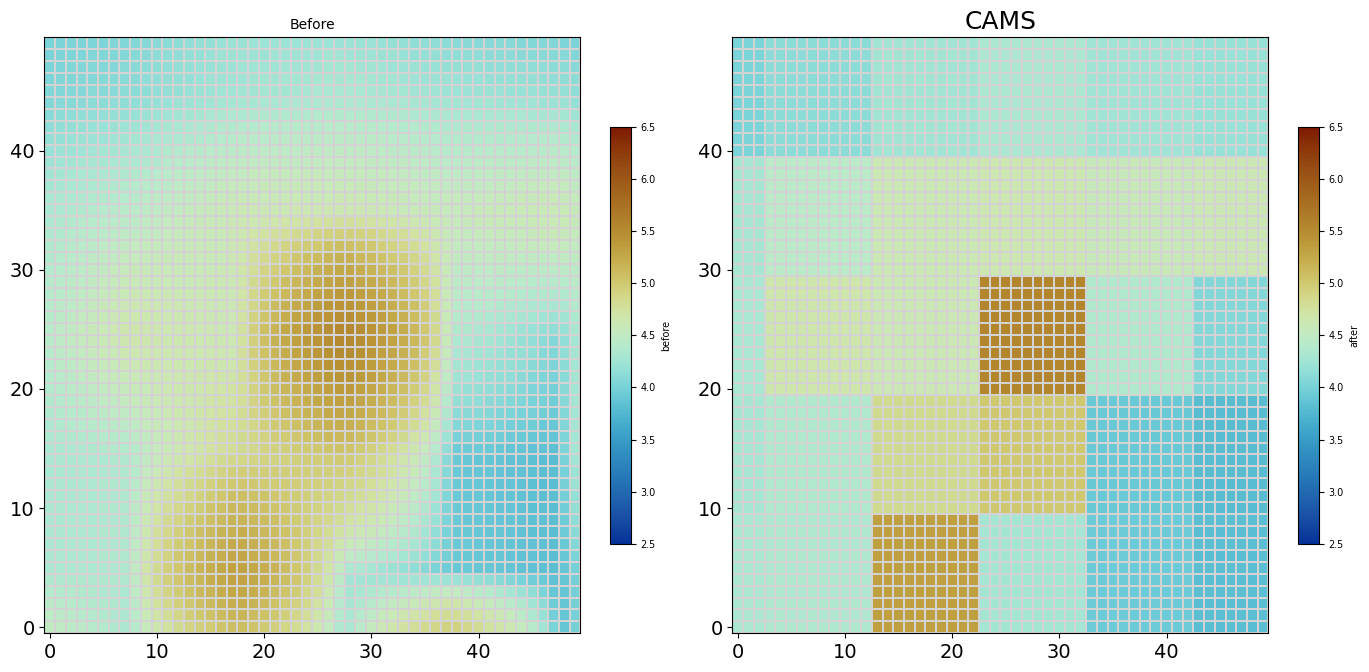

/var/folders/b2/4zv441n11_s6ww9psppcn0s80000gn/T/ipykernel_5081/3560889166.py:87: RuntimeWarning: divide by zero encountered in log10
  x, y, np.log10(eagrid_before),


TypeError: Dimensions of C (60, 40) should be one smaller than X(50) and Y(50) while using shading='flat' see help(pcolormesh)

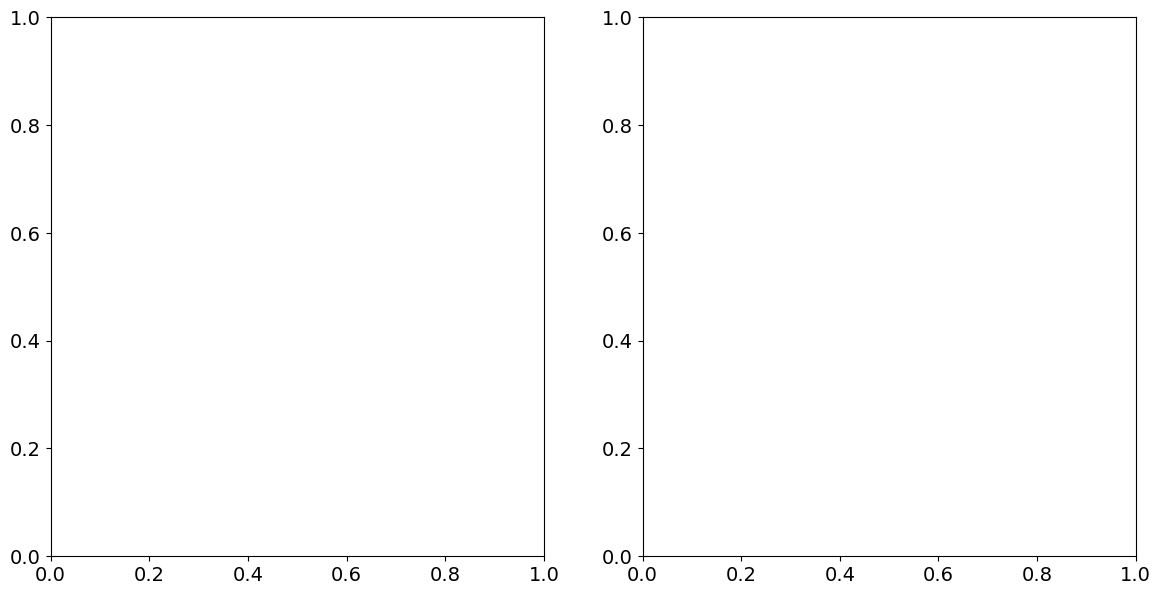

In [16]:
plot_testdata(center_lon=139.75, center_lat=35.68)